In [19]:
from langgraph.graph import StateGraph,START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [20]:
load_dotenv()

True

In [21]:
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

In [22]:
# create state

class BlogState(TypedDict):
    title:str
    outline:str
    content:str

In [23]:
def create_outline(state:BlogState)->BlogState:
    # fetch title

    title=state['title']

    # call llm gen outline

    prompt=f'generate an detailed outline for a blog on the topic - {title}'
    outline=model.invoke(prompt).text

    # update state

    state['outline']=outline

    return state

In [24]:
def create_blog(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']

    prompt=f'generate a detailed blog on the title - {title} using the following outline \n {outline} '
    content=model.invoke(prompt).text

    state['content']=content
    return state

In [25]:
# create graph

graph=StateGraph(BlogState)

# add nodes

graph.add_node('create_outline',create_outline)

graph.add_node('create_blog',create_blog)

# add edges

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow=graph.compile()


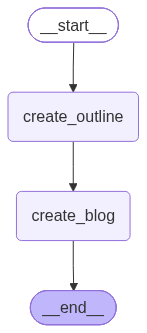

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_state={'title':'rise of ai in india'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'rise of ai in india', 'outline': 'Here is a detailed, SEO-optimized blog post outline on the topic **"The Rise of AI in India: How the Tech Giant is Shaping the Future of Artificial Intelligence."**\n\n---\n\n# Blog Post Title Options:\n1. **Catchy:** *From IT Hub to AI Powerhouse: The Rise of Artificial Intelligence in India*\n2. **SEO-Focused:** *The Rise of AI in India: Startups, Government Initiatives, and Economic Impact*\n3. **Thought Leadership:** *AI for All: How India is Democratizing Artificial Intelligence*\n\n---\n\n## **Estimated Word Count:** 1,800 – 2,500 words\n## **Target Audience:** Tech professionals, entrepreneurs, investors, policy enthusiasts, and general readers interested in India\'s tech ecosystem.\n\n---\n\n# **Detailed Blog Outline**\n\n### **1. Catchy Introduction (Approx. 150–200 words)**\n* **The Hook:** Start with a striking stat or metaphor (e.g., How India transformed from the world\'s back-office IT provider to a frontline innovator in Artif

: 